In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [14]:
#define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str


In [15]:
#function to calculate bmi
def calculate_bmi(state: BMIState) -> BMIState:    #take the state as input and return the state as output

    #get the values required for calculation from the state
    weight = state['weight_kg']
    height = state['height_m']

    #calculate bmi
    bmi = weight / (height ** 2)

    #update the state with the calculated bmi
    state['bmi'] = round(bmi, 2)

    return state

#function to categorize bmi
def categorize_bmi(state: BMIState) -> BMIState:    #take the state as input and return the state as output

    #get the bmi value from the state
    bmi = state['bmi']

    #categorize bmi
    if bmi < 18.5:
        category = 'Underweight'
    elif 18.5 <= bmi < 25:
        category = 'Normal weight'
    elif 25 <= bmi < 30:
        category = 'Overweight'
    else:
        category = 'Obesity'

    #update the state with the categorized bmi
    state['category'] = category

    return state

In [16]:
#define the graph
graph = StateGraph(BMIState)  #while creating the graph, we need to provide the state. 

#add nodes to the graph
graph.add_node("calculate_bmi", calculate_bmi)  #first arg is the name of the node and the second arg is the function that will be executed. 
graph.add_node("categorize_bmi", categorize_bmi)  #first arg is the name of the node and the second arg is the function that will be executed. We will implement this function later.

#as the flow is like 
#START -> calculate_bmi -> Categorize BMI -> END so the edges will be like below 

#add edges to the graph
graph.add_edge(START, "calculate_bmi")  #first arg is the source node and the second arg is the destination node.
graph.add_edge("calculate_bmi", "categorize_bmi")  #first arg is the source node and the second arg is the destination node.
graph.add_edge("categorize_bmi", END)  #first arg is the source node and the second arg is the destination node.

#compile the graph 
workflow = graph.compile()  #compiling the graph will check for any errors in the graph and prepare it for execution.



In [17]:
#execute the graph
workflow.invoke({'weight_kg': 70, 'height_m': 1.75})  #invoke the workflow with the initial state. 
#The initial state should have the values required for the first node in the graph.
#this is also a state 

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}

In [18]:
#for better understading
initial_state = {'weight_kg': 70, 'height_m': 1.75}  #this is the initial state that we will pass to the workflow.\
final_state = workflow.invoke(initial_state)  #invoke the workflow with the initial state and get the final state after execution.
print(final_state)  #print the final state after execution.

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


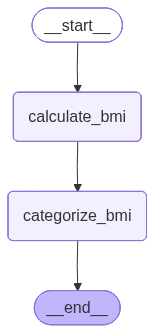

In [23]:
#lets visualize the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())  #this will visualize the graph. We can see the nodes and edges